# Plateau’s Problem for Enneper surface

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
<!-- More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2. -->

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.model_architecture import GeneralNet
from external.preconditioning.optimizers import HandNGD 

## Point-sampler
from GINN.numerical_boundary import find_boundary_points_numerically_with_binsearch
from models.net_w_partials import NetWithPartials
from util.sample_utils import precompute_sample_grid

torch.manual_seed(0)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

### True Surface

In [3]:
from util.visualization.utils_mesh import get_mesh

# Parametric equations for Enneper's minimal surface in polar coordinates
def enneper_surface_polar(r, phi):
    x = r * torch.cos(phi) - (1/3) * r**3 * torch.cos(3 * phi)
    y = r * torch.sin(phi) + (1/3) * r**3 * torch.sin(3 * phi)
    z = r**2 * torch.cos(2 * phi)
    return x, y, z

    
def enneper_level_set(v):
    x = v[:, 0]
    y = v[:, 1]
    z = v[:, 2]
    
    term1 = y**2 - x**2 + (4/3)*z + (4/9)*z**3
    term2 = y**2 - x**2 + (8/9)*z - z*(x**2 + y**2 + (8/9)*z**2)
    output = term1**3 - 3*z*term2**2
    return output

# def enneper_level_set(v):
#     x = v[:, 0]/3
#     y = v[:, 1]/3
#     z = v[:, 2]/3

#     output = (
#         64 * z**9 - 128 * z**7 + 64 * z**5 
#         - 702 * x**2 * y**2 * z**3 - 18 * x**2 * y**2 * z 
#         + 144 * (y**2 * z**6 - x**2 * z**6)
#         + 162 * (y**4 * z**2 - x**4 * z**2) 
#         + 27 * (y**6 - x**6) 
#         + 9 * (x**4 * z + y**4 * z) 
#         + 48 * (x**2 * z**3 + y**2 * z**3)
#         - 432 * (x**2 * z**5 + y**2 * z**5) 
#         + 81 * (x**4 * y**2 - x**2 * y**4) 
#         + 240 * (y**2 * z**4 - x**2 * z**4) 
#         - 135 * (x**4 * z**3 + y**4 * z**3)
#     )
    
#     return output



# Bounds and number of samples
n = 1000
# r_max = 1.0
r_max = 0.9
phi = torch.linspace(-torch.pi, torch.pi, n, dtype=torch.float64)
# phi = torch.linspace(-1, 1, n, dtype=torch.float64)

# Generate boundary points with r constant and phi ranging from -pi to pi
r_constant = torch.full_like(phi, r_max, dtype=torch.float64)
x, y, z = enneper_surface_polar(r_constant, phi)
pts_boundary = torch.vstack([x, y, z]).T

# Generate the mesh using the level set function
verts, faces = get_mesh(
    enneper_level_set, N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)
# verts, faces = get_mesh(
#     model.float(), N=128, device=device,
#     bbox_min=torch.tensor([-0.85, -0.85, -0.85], dtype=torch.float64),
#     bbox_max=torch.tensor([0.85, 0.85, 0.85], dtype=torch.float64),
#     chunks=2
# )

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()


/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

### Pretraining

In [4]:
# Generate random training points
model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)  # Assuming domain is [-1,1]^3
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]


# Define pretraining loss
def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)  # Ensure inputs are float64
    targets = pts[:, 2].to(dtype=torch.float64)  # Ensure targets are also float64
    preds = model(inputs).squeeze(1)  # Get model predictions
    return 0.5 * (preds - targets).square().mean()  # MSE loss

# Pretraining loop
pretrain_optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss = {loss.item():.6f}")

print("Pretraining completed!")


Pretrain Iter 0: Loss = 0.293926
Pretrain Iter 100: Loss = 0.000395
Pretrain Iter 200: Loss = 0.000327
Pretrain Iter 300: Loss = 0.000275
Pretrain Iter 400: Loss = 0.000229
Pretrain Iter 500: Loss = 0.000191
Pretrain Iter 600: Loss = 0.000160
Pretrain Iter 700: Loss = 0.000136
Pretrain Iter 800: Loss = 0.000117
Pretrain Iter 900: Loss = 0.000103
Pretraining completed!


### Surface Sampling and Error Metrics

In [5]:
def sample_true_surface(n_samples):
    # Generate radial and angular coordinates
    # r = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    r = torch.linspace(-0.9, 0.9, n_samples, dtype=torch.float64)
    phi = torch.linspace(-torch.pi, torch.pi, 2*n_samples, dtype=torch.float64)
    
    # Create a grid of r and phi
    r, phi = torch.meshgrid(r, phi, indexing='ij')

    # Compute the x, y, z coordinates using the parametric equations
    x, y, z = enneper_surface_polar(r.flatten(), phi.flatten())
    points_on_surface = torch.vstack([x, y, z]).T

    return points_on_surface

def sample_model_surface_newton(model, init_points, n_iter=10, newton_clip=0.15, tol=1e-8):

    # n_samples = 64
    # r = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    # phi = torch.linspace(-torch.pi, torch.pi, n_samples, dtype=torch.float64)
    # r, phi = torch.meshgrid(r, phi, indexing='ij')
    # r = r.flatten()
    # phi = phi.flatten()
    # x = r * torch.cos(phi)
    # y = r * torch.sin(phi)
    # z = torch.zeros_like(x)
    # init_points = torch.vstack([x, y, z]).T

    for _ in range(n_iter):
        init_points.requires_grad_(True)
        f_val = model(init_points)  # Evaluate function value
        
        # Compute gradient
        # grad_f = torch.autograd.grad(f_val.sum(), init_points, create_graph=True)[0]
        grad_f = model.vf_x(model.params, init_points).squeeze(1)

        # Avoid division by small gradients
        grad_norm_sq = torch.sum(grad_f**2, dim=1, keepdim=True)
        valid = grad_norm_sq.squeeze() > 1e-10
        step = torch.zeros_like(init_points)
        
        # Newton step: p_new = p_old - f(p) * grad_f / ||grad_f||^2
        step[valid] = (f_val[valid] / grad_norm_sq[valid]) * grad_f[valid]
        step = torch.clamp(step, -newton_clip, newton_clip)  # Clip updates

        init_points = init_points - step.detach()

        # Stop early if all points are close to zero level set
        if torch.max(torch.abs(f_val)) < tol:
            break

    # Filter valid points (close to zero level set)
    valid_mask = torch.abs(f_val) < tol
    valid_mask = valid_mask.squeeze(1)
    points_on_surface = init_points[valid_mask].detach()
    
    return points_on_surface

def sample_model_surface_binsearch(model):
    netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
    bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
    grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
            10000, bounds, equidistant=True)

    success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
        netp=netp, 
        z=torch.zeros([1,0], dtype=torch.float64),
        n_steps=10,
        x_grid=grid_find_surface, 
        x_grid_dist=grid_dist_find_surface, 
        level_set=0.0,
        nf_is_density=True,
        resolution=init_grid_resolution
        )
    if success:
        points_on_surface = p_surface.data
        points_on_surface = torch.cat((pts_boundary, points_on_surface))
    # else:
    #     x = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    #     y = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    #     z = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
        
    #     xx, yy, zz = torch.meshgrid(x, y, z, indexing='ij')
    #     grid_points = torch.stack([xx.flatten(), yy.flatten(), zz.flatten()], dim=1)
        
    #     with torch.no_grad():
    #         values = model(grid_points).squeeze()
    #         mask = torch.isclose(values, torch.zeros_like(values), atol=1e-4)  # Adjust tolerance
    #         points_on_surface = grid_points[mask]
        
    return points_on_surface

def compute_distance(model, true_implicit, pts_surface_model, pts_surface_true):    

    # Refine model surface samples for exact error calculation
    pts_surface_model = sample_model_surface_newton(model, pts_surface_model)
    # Cut away points further away than the boundary points
    distances = torch.norm(pts_surface_model, dim=1)
    # pts_surface_model = pts_surface_model[distances <= 1.2]
    pts_surface_model = pts_surface_model[distances <= 1.0]

    # Compute the integral of squared values over both surfaces
    with torch.no_grad():
        d_model = model(pts_surface_true).squeeze().square().mean()
        d_true = true_implicit(pts_surface_model).squeeze().square().mean()
        distance = torch.sqrt(d_model + d_true).item()

    return distance

def chamfer_disc(model, pts_surface_true):    

    # Refine model surface samples for exact error calculation
    pts_surface_model = sample_model_surface_newton(model, pts_surface_true)
    # Cut away points further away than the boundary points
    # distances = torch.norm(pts_surface_model, dim=1)
    # pts_surface_model = pts_surface_model[distances <= 1.2]
    
    dists = torch.cdist(pts_surface_model, pts_surface_true, p=2) ** 2  # Shape (M, N)
    # For each x in Q (model surface), find the closest y in P (true surface)
    min_dists, _ = dists.min(dim=1)  # Shape (M,)
    # Compute Chamfer divergence
    distance = min_dists.mean()

    return torch.sqrt(distance).item()

netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
pts_surface_true = sample_true_surface(64)
# pts_surface_true = sample_true_surface(512)
# pts_surface_model = sample_model_surface_binsearch(model.double())
# distance = compute_distance(model.double(), enneper_level_set, pts_surface_model, pts_surface_true)
distance = chamfer_disc(model, pts_surface_true)
print(f"Distance d(f_i, f_j): {distance}")


Distance d(f_i, f_j): 0.12432885504505942


In [6]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1.5, -1.5, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1.5, 1.5, 1], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb


fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(pts_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()

### Main training loop

In [7]:
# pts_space = torch.rand([1000, 3], dtype=torch.float64)
# pts_space_fixed = torch.rand([1000, 3], dtype=torch.float64)
pts_space = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_eikonal = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_eikonal = torch.cat((pts_eikonal, pts_boundary))
pts_surface = pts_boundary
# pts_eikonal = pts_boundary


# GN weights
loss_weights = {"interface": 1.0, "eikonal": 0.001, "curvature": 1.0}
# Adam weights
# loss_weights = {"interface": 1.0, "eikonal": 0.1, "curvature": 1.0}




config = {
    "pts_boundary": pts_boundary,
    "pts_eikonal": pts_eikonal,
    "pts_surface": pts_surface,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

  0%|          | 0/100000 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Best model loaded with loss 2.600941775610254e-10


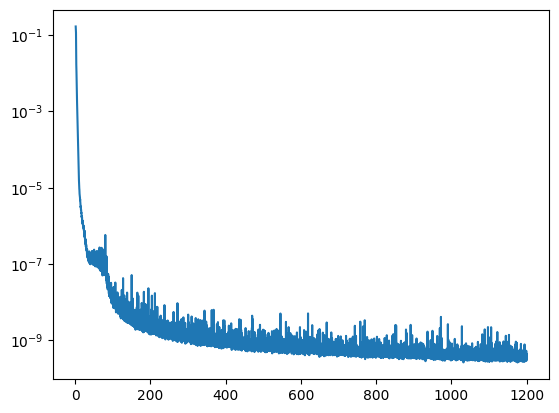

In [8]:
import time
import copy

model = model.double()
params = model.params
loss_over_time = {}
distance_over_time = {}
chamfer_over_time = {}
best_loss = float('inf')
# bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
# Gauss-Newton:
optim = HandNGD(model, lr=1e-1, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik
start_time = time.time()
current_time = 0
for i in (pbar:=trange(100000)):
    if current_time > 1200:
        break
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()

    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    if i == 500:
        loss_weights = {"interface": 1.0, "eikonal": 0.0, "curvature": 1.0}
        config["loss_weights"] = loss_weights
        optim.config = config

    pts_surface = sample_model_surface_binsearch(model)
    config["pts_surface"] = pts_surface
    optim.config = config
    
    loss_curvature = 0.5*model.v_f_mean_curvature(params, pts_surface).squeeze(1).square().mean()
       
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["curvature"] * loss_curvature

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_curvature
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()
        distance_over_time[current_time] = compute_distance(model.double(), enneper_level_set, pts_surface, pts_surface_true)
        chamfer_over_time[current_time] = chamfer_disc(model, pts_surface_true)

        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"curvature: {loss_curvature.item():.2e} "
                            # f"laplacian: {loss_laplacian.item():.2e} "
                            f"error: {chamfer_over_time[current_time]:.2e} "
                            f"{len(pts_surface)}"
                            )
    optim.step()

# Load the best model after training
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Best model loaded with loss {best_loss}")

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

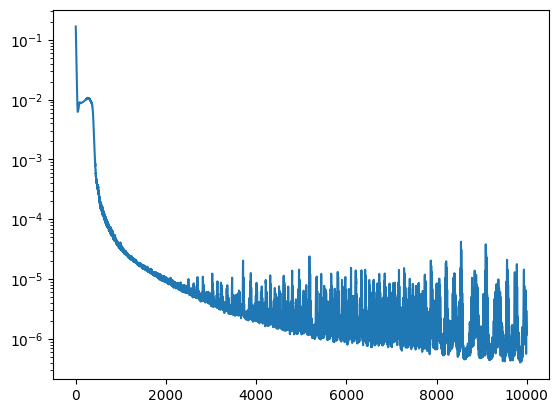

In [108]:
model = model.double()
params = model.params
loss_over_iters = {}
distance_over_iters = {}
chamfer_over_iters = {}
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
# Gauss-Newton:
# optim = HandNGD(model, lr=1e-1, config=config)
# Adam:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik
for i in (pbar:=trange(10000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    if i == 500:
        loss_weights = {"interface": 1.0, "eikonal": 0.0, "curvature": 1.0}
        config["loss_weights"] = loss_weights
        optim.config = config

    pts_surface = sample_model_surface_binsearch(model)
    config["pts_surface"] = pts_surface
    optim.config = config
    
    loss_curvature = 0.5*model.v_f_mean_curvature(params, pts_surface).squeeze(1).square().mean()
       
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["curvature"] * loss_curvature

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_curvature
        loss_over_iters[i] = loss_metric.item()
        distance_over_iters[i] = compute_distance(model.double(), enneper_level_set, pts_surface, pts_surface_true)
        chamfer_over_iters[i] = chamfer_disc(model, pts_surface_true)
        

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"curvature: {loss_curvature.item():.2e} "
                            # f"laplacian: {loss_laplacian.item():.2e} "
                            f"error: {chamfer_over_iters[i]:.2e} "
                            f"{len(pts_surface)}"
                            )
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

### Visualize the result

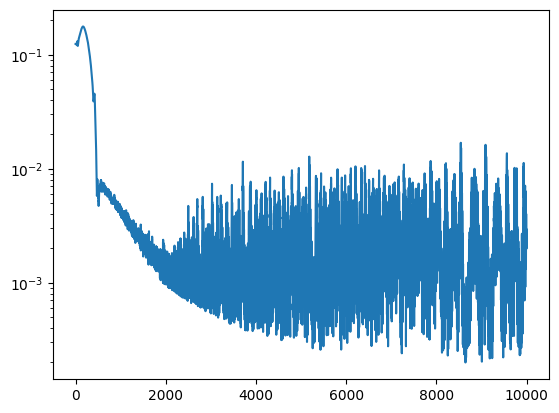

In [109]:
plt.plot(chamfer_over_iters.keys(), chamfer_over_iters.values())
plt.semilogy()
plt.show()

In [113]:
loss_file = "dist_over_iters_enneper_adam.pth"
torch.save(distance_over_iters, loss_file)
print(f"Loss saved to {loss_file}")

Loss saved to dist_over_iters_enneper_adam.pth


In [96]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-0.85, -0.85, -0.85], dtype=torch.float64),
    bbox_max=torch.tensor([0.85, 0.85, 0.85], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb


fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(pts_surface_true.cpu().detach(), point_size=0.05)
# fig += k3d.points(pts_surface_model.cpu().detach(), point_size=0.05)
fig.display()

Output()

In [10]:
fig_output_file = "k3d_plot_heatmap_enneper_gn.html"
with open(fig_output_file, 'w') as f:
    f.write(fig.get_snapshot())
print(f"Plot saved to {fig_output_file}")

Plot saved to k3d_plot_heatmap_enneper_gn.html


In [15]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-0.85, -0.85, -0.85], dtype=torch.float64),
    bbox_max=torch.tensor([0.85, 0.85, 0.85], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

model.double()
mean_curvatures = model.v_f_mean_curvature(params, torch.tensor(verts, dtype=torch.float64)).squeeze(1).abs()


# Visualization
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)

# color_range = [-0.0125, 0]
color_map = k3d.basic_color_maps.Jet
color_range = [0, 0.005]

# Add the mesh with per-vertex curvature coloring
fig += k3d.mesh(
    verts, faces, 
    attribute=mean_curvatures.cpu().detach().numpy().astype(np.float32),
    color_range=color_range,
    color_map=color_map,
    side='double',
    flat_shading=False
)

# Add additional points
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

Output()

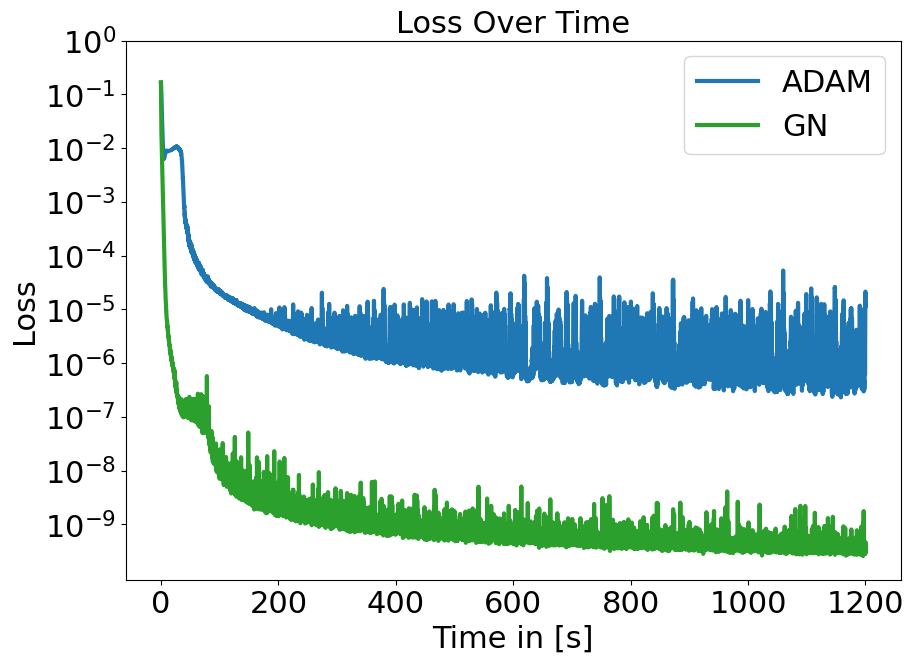

loss_over_iters_enneper.png


In [126]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_time_enneper_adam.pth")
loss_over_iters_gn = torch.load("loss_over_time_enneper_gn.pth")

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

plt.figure(figsize=(10, 7))

plt.plot(adam_iterations, adam_values, label="ADAM", linewidth=3, color="tab:blue")
plt.plot(gn_iterations, gn_values, label="GN", linewidth=3, color="tab:green")



plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Time in [s]", fontsize=22)
plt.ylabel("Loss", fontsize=22)
plt.title("Loss Over Time", fontsize=22)
plt.legend(fontsize=22, loc="upper right")
plt.xticks(fontsize=22)
plt.yticks(np.logspace(start=-9, stop=0, num=10), fontsize=22)
plt.savefig("a_output.png")
plt.show()
print("loss_over_iters_enneper.png")




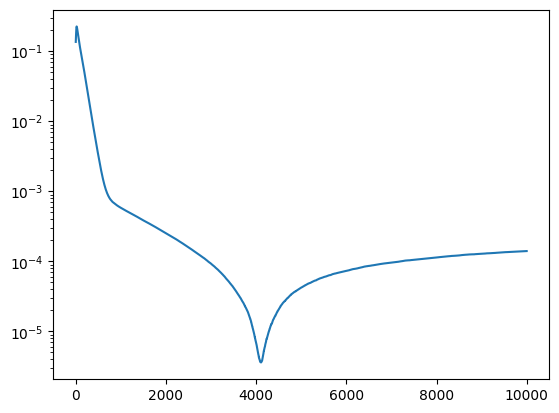

In [82]:
plt.plot(chamfer_over_iters.keys(), chamfer_over_iters.values())
plt.semilogy()
plt.show()

In [12]:
loss_file = "loss_over_time_enneper_adam.pth"
torch.save(loss_over_time, loss_file)
print(f"Loss saved to {loss_file}")

Loss saved to loss_over_time_enneper_adam.pth


In [67]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(pts_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()